## 12 RL-Dispatch

**笔记本**：`12 rl_dispatch_sz.ipynb`

**库**：`pandas`、`numpy`、`geopandas`、`matplotlib` 等。

**输入**：
- `data_raw/RL-Dispatch_SZ_order.csv`（课程数据，勿将大文件提交公开仓库）
- `../03 Boundary/data_out/shenzhen_boundary.geojson` 或 `../04 Transport/data_raw/shenzhen_boundary.geojson`
- 格网（与 08 一致）：优先 `../08 POI Demand/data_out/sz_demand_grid.gpkg`，否则 `../../viz/public/data/demand_grid.json`

**做了什么 / 算了什么**：
- 分块读取订单 CSV；计算 **Haversine 直线距离**（km）；**duration_min** = 发单至收餐的分钟差，跨日则 `+1440`。按坐标范围、时长上限、距离上下限等 **过滤**；可选与深圳边界 **裁切**。
- 把真实派单和 demand 格网并起来做对照：将订单 **空间连接到 demand 格网**，聚合格网订单量、时长加权和、**24h 发单分布**；抽取建模用随机子样本等。如果相关性明显为正，那就说明：你们的 demand 指标不是乱造的，确实和实际配送活动有对应。
-看 24 小时发单节律
-做描述性分布和空间热力
-做一个简单预测模型


**写出文件**（均在 `data_out/`，具体以 notebook 内路径为准）：
- `sz_dispatch_grid_agg.gpkg`
- `dispatch_demand_compare.csv` 及分析图表

**典型输出信息**：格网来源与单元数、分块扫描行数、过滤后样本量、格网聚合与 CSV 保存路径。

**说明**：此处的 **经验端到端时效** 与 **10** 中路网 `travel_time` 含义不同，不可直接等同。
- 1. 直线距离不是实际配送距离，所以 dist_km 只能当简化 proxy。
- 2. 时长受很多未观测因素影响，比如：骑手行为，取餐等待，商户出餐，天气，电梯/门禁，平台调度；所以模型解释度不一定很高，这很正常。
- 3. 格网聚合只看送达点，这更偏需求落点，不一定完整表示整条配送链。
- 4. 如果订单样本不全或偏某类平台；那它只能代表样本中的业务场景，不是全深圳全部物流。

In [1]:
#https://tianchi.aliyun.com/dataset/106807
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path(".")
OUT = ROOT / "data_out"
OUT.mkdir(exist_ok=True)

RL_CSV = ROOT / "data_raw" / "RL-Dispatch_SZ_order.csv"
BOUNDARY = Path("../03 Boundary/data_out/shenzhen_boundary.geojson")
BOUNDARY_ALT = Path("../04 Transport/data_raw/shenzhen_boundary.geojson")
GRID_GPKG = Path("../08 POI Demand/data_out/sz_demand_grid.gpkg")
GRID_JSON = Path("../../viz/public/data/demand_grid.json")

CHUNK_ROWS = 150_000
DURATION_MAX_MIN = 180
DIST_MIN_KM = 0.02
DIST_MAX_KM = 60
ML_SAMPLE_TARGET = 250_000
RNG = np.random.default_rng(42)


def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized great-circle distance km."""
    R = 6371.0
    la1 = np.radians(lat1)
    la2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin(dlmb / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(np.maximum(0.0, 1 - a)))
    return R * c


def add_duration_and_filter(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    cols = [
        "sender_latitude", "sender_longitude",
        "receiver_latitude", "receiver_longitude",
        "send_hour", "send_minute", "receive_hour", "receive_minute", "order_cnt",
    ]
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=cols)
    df["order_cnt"] = df["order_cnt"].fillna(1).clip(lower=1)
    send_m = df["send_hour"].astype(int) * 60 + df["send_minute"].astype(int)
    recv_m = df["receive_hour"].astype(int) * 60 + df["receive_minute"].astype(int)
    dur = recv_m - send_m
    dur = dur.where(dur >= 0, dur + 24 * 60)
    df["duration_min"] = dur.astype(float)
    df["dist_km"] = haversine_km(
        df["sender_latitude"].values, df["sender_longitude"].values,
        df["receiver_latitude"].values, df["receiver_longitude"].values,
    )
    df = df[
        (df["receiver_latitude"].between(22.35, 22.95))
        & (df["receiver_longitude"].between(113.65, 114.75))
        & (df["duration_min"] > 0)
        & (df["duration_min"] <= DURATION_MAX_MIN)
        & (df["dist_km"] >= DIST_MIN_KM)
        & (df["dist_km"] <= DIST_MAX_KM)
    ]
    return df


# ── 边界（可选裁切展示） ──
if BOUNDARY.exists():
    sz = gpd.read_file(BOUNDARY).to_crs(4326)
elif BOUNDARY_ALT.exists():
    sz = gpd.read_file(BOUNDARY_ALT).to_crs(4326)
else:
    sz = None
    print("未找到边界 geojson，跳过界内过滤（仅用坐标范围）")

# ── 与 08 一致的格网 ──
if GRID_GPKG.exists():
    grid_full = gpd.read_file(GRID_GPKG).to_crs(4326)
    print(f"格网来源: GPKG  {len(grid_full):,} cells")
elif GRID_JSON.exists():
    grid_full = gpd.read_file(GRID_JSON).to_crs(4326)
    print(f"格网来源: JSON  {len(grid_full):,} cells")
else:
    grid_full = None
    print("错误: 未找到 demand 格网。请先运行 08 生成 gpkg，或保留 viz/public/data/demand_grid.json")

grid = grid_full[["h3_id", "geometry"]].copy() if grid_full is not None else None

格网来源: GPKG  2,754 cells


## 1）清洗 + 耗时 + 距离（分块扫描全表）

累计：格网订单量与时长加权和、24h 发单计数、用于建模的随机子样本。

In [2]:
assert RL_CSV.exists(), f"未找到 {RL_CSV.resolve()} — 请将 CSV 放在 Data/ 下或修改 RL_CSV"
assert grid is not None, "需要 demand 格网"

sz_union = None
if sz is not None:
    sz_union = sz.union_all() if hasattr(sz, "union_all") else sz.unary_union

grid_n = pd.Series(dtype=float)
grid_dw = pd.Series(dtype=float)
hour_send = np.zeros(24, dtype=np.float64)
n_rows_ok = 0
n_chunks = 0
ml_parts = []
ml_accum = 0
p_ml = min(1.0, ML_SAMPLE_TARGET / 1_500_000)

for chunk in pd.read_csv(RL_CSV, chunksize=CHUNK_ROWS):
    n_chunks += 1
    if "Unnamed: 0" in chunk.columns:
        chunk = chunk.drop(columns=["Unnamed: 0"])
    chunk = add_duration_and_filter(chunk)
    if chunk.empty:
        continue
    if sz_union is not None:
        gchk = gpd.GeoDataFrame(
            chunk,
            geometry=gpd.points_from_xy(chunk["receiver_longitude"], chunk["receiver_latitude"]),
            crs=4326,
        )
        gchk = gchk[gchk.within(sz_union)]
        chunk = pd.DataFrame(gchk.drop(columns="geometry"))
    if chunk.empty:
        continue
    n_rows_ok += len(chunk)
    sh = chunk["send_hour"].astype(int).clip(0, 23)
    hour_send += np.bincount(sh.values, minlength=24)
    gdf = gpd.GeoDataFrame(
        chunk,
        geometry=gpd.points_from_xy(chunk["receiver_longitude"], chunk["receiver_latitude"]),
        crs=4326,
    )
    j = gpd.sjoin(gdf, grid, predicate="within")
    if len(j):
        j["dur_w"] = j["duration_min"] * j["order_cnt"]
        g = j.groupby("h3_id").agg(n=("order_cnt", "sum"), dw=("dur_w", "sum"))
        grid_n = grid_n.add(g["n"], fill_value=0)
        grid_dw = grid_dw.add(g["dw"], fill_value=0)
    if ml_accum < ML_SAMPLE_TARGET:
        take = RNG.random(len(chunk)) < p_ml * 2
        sub = chunk.loc[take, ["duration_min", "dist_km", "send_hour", "day"]].copy()
        ml_parts.append(sub)
        ml_accum = sum(len(x) for x in ml_parts)
    if n_chunks % 5 == 0:
        print(f"  chunks={n_chunks}, valid_rows≈{n_rows_ok:,}, ml_buf={ml_accum:,}")

df_ml = pd.concat(ml_parts, ignore_index=True) if ml_parts else pd.DataFrame()
if len(df_ml) > ML_SAMPLE_TARGET:
    df_ml = df_ml.sample(n=ML_SAMPLE_TARGET, random_state=42).reset_index(drop=True)

if len(grid_n) == 0:
    grid_agg = pd.DataFrame(columns=["h3_id", "dispatch_orders", "mean_duration_min"])
else:
    tbl = pd.concat([grid_n.rename("dispatch_orders"), grid_dw.rename("dur_w")], axis=1).fillna(0)
    tbl["mean_duration_min"] = np.where(tbl["dispatch_orders"] > 0, tbl["dur_w"] / tbl["dispatch_orders"], np.nan)
    grid_agg = tbl.reset_index().rename(columns={"index": "h3_id"})

print(f"\n完成: 有效行≈{n_rows_ok:,}, 覆盖格网数={(grid_agg['dispatch_orders']>0).sum():,}, 建模样本={len(df_ml):,}")

  chunks=5, valid_rows≈610,071, ml_buf=203,420
  chunks=10, valid_rows≈1,220,892, ml_buf=284,446

完成: 有效行≈1,226,081, 覆盖格网数=1,179, 建模样本=250,000


## 2）与 08 demand 同格网合并 + 对照散点图

仅保留 `dispatch_orders>0` 与 `demand_pressure` 可比的格网；输出 `dispatch_demand_compare.csv` 与带几何的 `sz_dispatch_grid_agg.gpkg`。

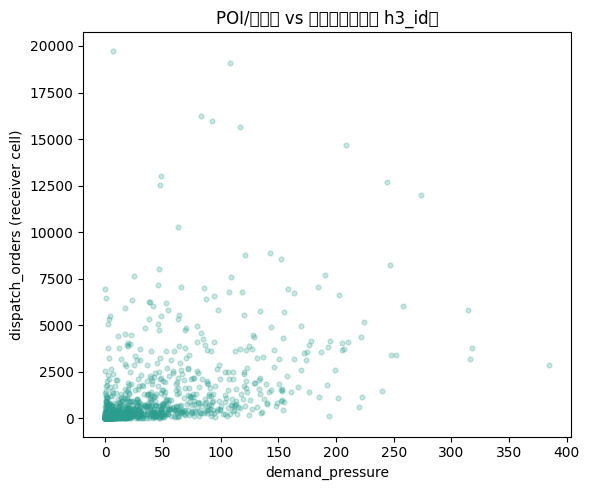

Spearman rho (demand vs dispatch) = 0.675, p = 8.88e-158
已写 data_out/dispatch_demand_compare.csv 与 data_out/sz_dispatch_grid_agg.gpkg


In [3]:
demand_col = "demand_pressure" if "demand_pressure" in grid_full.columns else None
if demand_col is None:
    for c in ("demand_pressure_norm", "poi_total"):
        if c in grid_full.columns:
            demand_col = c
            break

merged = grid_full.merge(grid_agg, on="h3_id", how="left")
merged["dispatch_orders"] = merged["dispatch_orders"].fillna(0)
cmp = merged[merged["dispatch_orders"] > 0].copy()
if demand_col:
    cmp = cmp[cmp[demand_col].notna()]

fig, ax = plt.subplots(figsize=(6, 5))
if demand_col and len(cmp):
    ax.scatter(cmp[demand_col], cmp["dispatch_orders"], alpha=0.25, s=12, c="#2a9d8f")
    ax.set_xlabel(demand_col)
else:
    ax.text(0.5, 0.5, "无 demand 列可对照", ha="center")
ax.set_ylabel("dispatch_orders (receiver cell)")
ax.set_title("POI/需求层 vs 真实订单量（同 h3_id）")
plt.tight_layout()
plt.show()

try:
    from scipy import stats
    if demand_col and len(cmp) > 10:
        r, p = stats.spearmanr(cmp[demand_col], cmp["dispatch_orders"])
        print(f"Spearman rho (demand vs dispatch) = {r:.3f}, p = {p:.2e}")
except Exception as e:
    print("Spearman:", e)

cols = ["h3_id", "dispatch_orders", "mean_duration_min"]
if demand_col:
    cols.insert(1, demand_col)
cmp_out = cmp[[c for c in cols if c in cmp.columns]]
cmp_out.to_csv(OUT / "dispatch_demand_compare.csv", index=False)
merged.to_file(OUT / "sz_dispatch_grid_agg.gpkg", driver="GPKG")
print(f"已写 {OUT / 'dispatch_demand_compare.csv'} 与 {OUT / 'sz_dispatch_grid_agg.gpkg'}")

## 3）24h 发单峰谷（`send_hour`）

按清洗后保留的订单统计发单小时分布（receiver 在深圳边界内）。

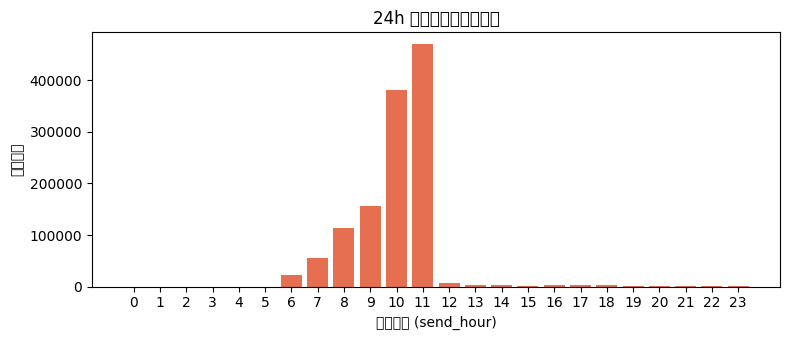

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(np.arange(24), hour_send, color="#e76f51", edgecolor="none")
ax.set_xticks(np.arange(24))
ax.set_xlabel("发单小时 (send_hour)")
ax.set_ylabel("订单行数")
ax.set_title("24h 发单分布（清洗后）")
plt.tight_layout()
plt.show()

## 4）描述性：时长分布、距离-时长、格网订单热力

基于 `df_ml` 子样本与 `merged` 面数据。

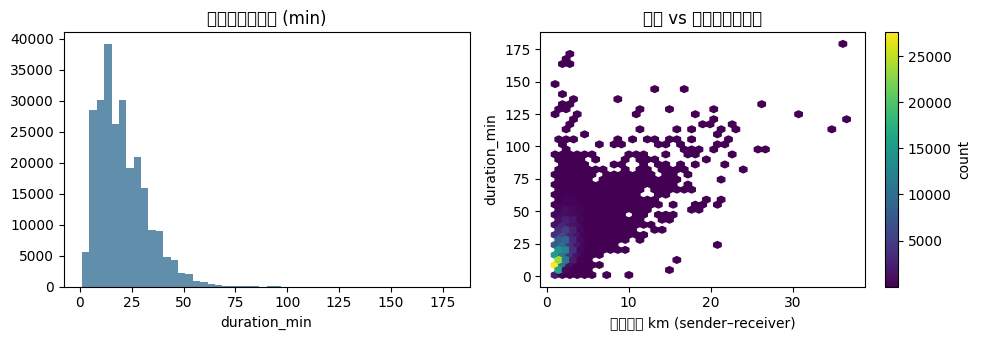

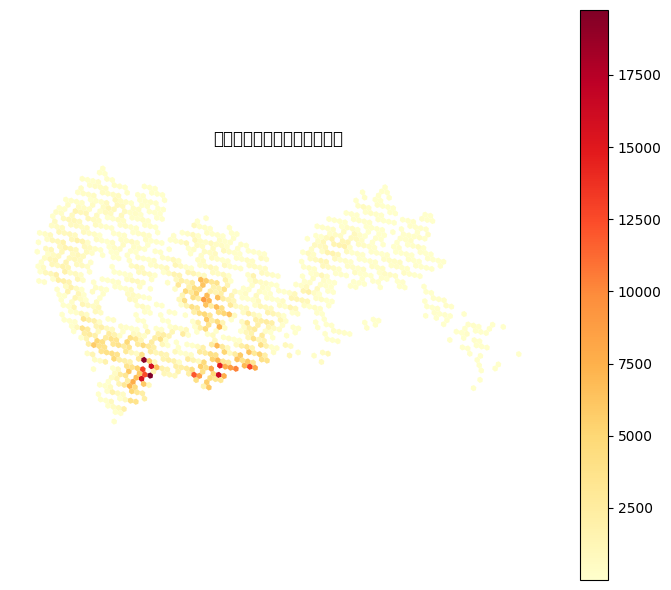

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
if len(df_ml):
    axes[0].hist(df_ml["duration_min"], bins=50, color="#457b9d", alpha=0.85)
    axes[0].set_xlabel("duration_min")
    axes[0].set_title("经验端到端时长 (min)")
    hb = axes[1].hexbin(df_ml["dist_km"], df_ml["duration_min"], gridsize=40, cmap="viridis", mincnt=1)
    axes[1].set_xlabel("直线距离 km (sender–receiver)")
    axes[1].set_ylabel("duration_min")
    axes[1].set_title("距离 vs 时长（子样本）")
    plt.colorbar(hb, ax=axes[1], label="count")
else:
    for ax in axes:
        ax.text(0.5, 0.5, "无建模样本", ha="center", transform=ax.transAxes)
plt.tight_layout()
plt.show()

plot_gdf = merged[merged["dispatch_orders"] > 0].copy()
if len(plot_gdf):
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    plot_gdf.plot(column="dispatch_orders", ax=ax, legend=True, cmap="YlOrRd", markersize=0, linewidth=0.2)
    ax.set_title("格网：送达端订单量（热力）")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 5）预测：送达时长 ~ 距离 + 发单小时 + day（数据驱动，非路网）

使用上一步固定的 `duration_min` 定义；与 10 的 OSM travel time 是两条线。

In [6]:
if len(df_ml) < 500:
    print("建模样本过少，跳过回归")
else:
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_absolute_error, r2_score

    X = df_ml[["dist_km", "send_hour", "day"]].astype(float)
    y = df_ml["duration_min"].astype(float)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lin = LinearRegression().fit(X_train, y_train)
    y_p = lin.predict(X_test)
    print("── LinearRegression ──")
    print(f"  MAE (min): {mean_absolute_error(y_test, y_p):.2f}")
    print(f"  R2:        {r2_score(y_test, y_p):.3f}")
    print(f"  coef: dist={lin.coef_[0]:.3f}, hour={lin.coef_[1]:.3f}, day={lin.coef_[2]:.3f}, intercept={lin.intercept_:.2f}")

    rf = RandomForestRegressor(n_estimators=60, max_depth=12, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_rf = rf.predict(X_test)
    print("── RandomForest (60 trees) ──")
    print(f"  MAE (min): {mean_absolute_error(y_test, y_rf):.2f}")
    print(f"  R2:        {r2_score(y_test, y_rf):.3f}")
    print(f"  feature importances: dist={rf.feature_importances_[0]:.3f}, hour={rf.feature_importances_[1]:.3f}, day={rf.feature_importances_[2]:.3f}")

── LinearRegression ──
  MAE (min): 8.00
  R2:        0.244
  coef: dist=5.713, hour=0.983, day=-0.029, intercept=0.28
── RandomForest (60 trees) ──
  MAE (min): 7.62
  R2:        0.305
  feature importances: dist=0.810, hour=0.126, day=0.064
